## Movies Dataset 2024 - Grupo 9
<hr style="border:1px solid gray">

# 1. Exploración y Compresión de Datos

## 1.1. Carga del Dataset

Importar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe
from pathlib import Path
import shutil

Importar dataset

In [2]:
# Create data directory if it doesn't exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Download dataset (latest version by default)
download_path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Copy to local data directory
csv_file = next(Path(download_path).glob("*.csv"))
local_path = data_dir / csv_file.name
shutil.copy2(csv_file, local_path)

print(f"Dataset copied to: {local_path}")

Dataset copied to: data/TMDB_movie_dataset_v11.csv


Carga del dataset

In [3]:
# Cargamos el dataset desde el directorio local de datos
data_path = "data/TMDB_movie_dataset_v11.csv"
movies = pd.read_csv(data_path)

## 1.2. Descripción del dataset IMDB Movies 2024


| Variable              | Descripción                                                                                  |
|-----------------------|----------------------------------------------------------------------------------------------|
| `id`                  | Unique identifier for each movie. (type: int)                                                |
| `title`               | Title of the movie (usually in English or the display title). (type: str)                    |
| `vote_average`        | Average vote or rating given by viewers (typically 0–10 scale). (type: float)                |
| `vote_count`          | Total count of votes received for the movie. (type: int)                                     |
| `status`              | Current status of the movie (Released, Rumored, Post Production, etc.). (type: str)          |
| `release_date`        | Date when the movie was released (format usually YYYY-MM-DD). (type: str)                    |
| `revenue`             | Total revenue generated by the movie (in USD; 0 often means unknown/missing). (type: int)    |
| `runtime`             | Duration of the movie in minutes (0 usually means unknown). (type: int)                      |
| `adult`               | Indicates if the movie is only for adult audiences (true/false). (type: bool)                |
| `backdrop_path`       | Relative path to the backdrop image for the movie . (type: str)                              |
| `budget`              | Estimated production budget of the movie (USD; 0 often means unknown/missing). (type: int64) |
| `homepage`            | Official website URL of the movie (empty string or null if not available). (type: str)       |
| `imdb_id`             | IMDb identifier for the movie (format: tt followed by 7–8 digits). (type: str)               |
| `original_language`   | ISO 639-1 code of the original language of the movie (e.g., 'en', 'fr', 'es'). (type: str)   |
| `original_title`      | Original title of the movie (in its original language). (type: str)                          |
| `overview`            | Brief plot summary or synopsis of the movie. (type: str)                                     |
| `popularity`          | Popularity score assigned by TMDB (higher = more popular). (type: float64)                   |
| `poster_path`         | Relative path to the poster image for the movie (prepend https://image.tmdb.org) (type: str) |
| `tagline`             | Short marketing tagline or slogan of the movie (often empty). (type: str)                    |
| `genres`              | List of genres (usually as comma-separated string or JSON in some datasets). (type: str)     |
| `production_companies`| Name(s) of the main production company/companies (often comma-separated or JSON) (type: str) |
| `production_countries`| Country/countries where the movie was produced (often comma-separated or JSON). (type: str)  |
| `spoken_languages`    | Language(s) spoken in the movie (comma-separated or JSON. ISO codes and names). (type: str)  |
| `keywords`            | Descriptive keywords/tags linked with the movie (often comma-separated or JSON). (type: str) |



#### Tipos de Variables

Nota: 2 son columnas de ID: id, imdb_id

Numericas Continuas
- vote_average
- revenue
- budget
- popularity


Numericas Discretas
- vote_count
- runtime

Categoricas Nominales Binarias
- adult

Categoricas Nominales
- title
- release_date
- backdrop_path
- homepage
- original_language
- original_title
- overview
- poster_path
- tagline
- genres
- production_companies
- production_countries
- spoken_languages
- keywords

Categórica ordinal
- status

### Dimensiones del dataset original

In [4]:
print(f"Dimensiones del dataset original: {movies.shape}")
# exclude columns w/o valuable data (e.g. backdrop_path, imdb_id,..)
columns = ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'keywords']
movies[columns].head()

Dimensiones del dataset original: (1411545, 24)


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,keywords
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"new york city, superhero, shield, based on com..."


Informacion de columnas y tipo de datos

In [5]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1411545 entries, 0 to 1411544
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1411545 non-null  int64  
 1   title                 1411527 non-null  str    
 2   vote_average          1411545 non-null  float64
 3   vote_count            1411545 non-null  int64  
 4   status                1411545 non-null  str    
 5   release_date          1099739 non-null  str    
 6   revenue               1411545 non-null  int64  
 7   runtime               1411545 non-null  int64  
 8   adult                 1411545 non-null  bool   
 9   backdrop_path         351236 non-null   str    
 10  budget                1411545 non-null  int64  
 11  homepage              145259 non-null   str    
 12  imdb_id               666533 non-null   str    
 13  original_language     1411545 non-null  str    
 14  original_title        1411527 non-null  str  

In [6]:
movies[columns].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.411545e+06,1.411545e+06,1.411545e+06,1.411545e+06,1.411545e+06,1.411545e+06
mean,1.562050e+00,1.520135e+01,6.241432e+05,4.406251e+01,2.365181e+05,1.016805e+00
std,2.861550e+00,2.859140e+02,1.974778e+07,6.069186e+01,5.086599e+06,6.824018e+00
min,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-02
50%,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.070000e-01
max,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


## 1.3 Identificar patrones generales y distribuciones

### Análisis de las variables numéricas

_Nota: hay columnas con muchos valores en 0_

IMDB usa el 0 para representar "unknown", no el valor 0. Por eso usamos alternativamente las siguientes medidas para obtener resultados útiles:
- `field_valid = movies['field'][movies['field'] > 0]` # subset de valores mayores a 0
- `movies['field'].replace(0, np.nan).mode()` # reemplazar 0 por NaN

In [7]:
movies['budget'].median() # example w/o filtering 0s

np.float64(0.0)

In [8]:
budget_valid = movies['budget'][movies['budget'] > 0]
budget_valid.median() # iltering 0s

np.float64(3000.0)

In [9]:
movies['popularity'].mean() # example w/o filtering 0s

np.float64(1.0168050367808728)

In [10]:
movies['popularity'].replace(0, np.nan).mean() # example filtering 0s

np.float64(1.222475813215501)

#### Definir sets válidos para mostrar medidas no afectada por valores faltantes

In [11]:
budget_valid = movies['budget'][movies['budget'] > 0]
revenue_valid = movies['revenue'][movies['revenue'] > 0]
popularity_valid = movies['popularity'][movies['popularity'] > 0]
vote_count_valid = movies['vote_count'][movies['vote_count'] > 0]
vote_average_valid = movies['vote_average'][movies['vote_average'] > 0]
runtime_valid = movies['runtime'][movies['runtime'] > 0]

#### Max/Mins

In [12]:
# Maximum budget
max_budget = budget_valid.max()
print(f"Maximum budget: ${max_budget:,}")

# Minimum budget
min_budget = budget_valid.min()
print(f"Minimum budget: ${min_budget:,}")

# Maximum revenue
max_revenue = revenue_valid.max()
print(f"Maximum revenue: ${max_revenue:,}")

# Minimum revenue
min_revenue = revenue_valid.min()
print(f"Minimum revenue: ${min_revenue:,}")

# Maximum popularity
max_popularity = popularity_valid.replace(0, np.nan).max()
print(f"Maximum popularity: {max_popularity:,}")

# Minimum popularity
min_popularity = popularity_valid.replace(0, np.nan).min()
print(f"Minimum popularity: {min_popularity:,}")

# Maximum vote_average
max_vote_average = vote_average_valid.replace(0, np.nan).max()
print(f"Maximum vote_average: {max_vote_average:,}")

# Minimum vote_average
min_vote_average = vote_average_valid.replace(0, np.nan).min()
print(f"Minimum vote_average: {min_vote_average:,}")

# Maximum vote_count
max_vote_count = vote_count_valid.replace(0, np.nan).max()
print(f"Maximum vote_count: {max_vote_count:,}")

# Minimum vote_count
min_vote_count = vote_count_valid.replace(0, np.nan).min()
print(f"Minimum vote_count: {min_vote_count:,}")

# Maximum runtime
max_runtime = runtime_valid.replace(0, np.nan).max()
print(f"Maximum runtime: {max_runtime:,}")

# Minimum vote_count
min_runtime = runtime_valid.replace(0, np.nan).min()
print(f"Minimum runtime: {min_runtime:,}")

Maximum budget: $999,999,999
Minimum budget: $1
Maximum revenue: $4,999,999,999
Minimum revenue: $1
Maximum popularity: 2,994.357
Minimum popularity: 0.0071
Maximum vote_average: 10.0
Minimum vote_average: 0.5
Maximum vote_count: 34,495
Minimum vote_count: 1
Maximum runtime: 14,400
Minimum runtime: 1


#### Medidas de tendencia central: media, mediana y moda


#### Media

In [13]:
np.mean(budget_valid.replace(0, np.nan))    # Budget

np.float64(4144858.1216680943)

In [14]:
np.mean(revenue_valid.replace(0, np.nan)) # Revenue

np.float64(36525963.28063847)

In [15]:
np.mean(popularity_valid) # Popularity

np.float64(1.222475813215501)

In [16]:
np.mean(vote_count_valid.replace(0, np.nan)) # Vote count

np.float64(59.86093334151663)

In [17]:
np.mean(vote_average_valid.replace(0, np.nan)) # Vote average

np.float64(6.155837649121533)

In [18]:
np.mean(runtime_valid.replace(0, np.nan)) # Runtime

np.float64(63.724738579569554)

#### Mediana

In [19]:
np.median(budget_valid.replace(0, np.nan))  # Budget

np.float64(3000.0)

In [20]:
np.median(revenue_valid) # Revenue

np.float64(868260.0)

In [21]:
np.median(popularity_valid) # Popularity

np.float64(0.6)

In [22]:
np.median(vote_count_valid) # Vote count

np.float64(2.0)

In [23]:
np.median(vote_average_valid) # Vote average

np.float64(6.0)

In [24]:
np.median(runtime_valid) # Runtime

np.float64(62.0)

#### Moda

In [25]:
budget_valid.mode()[0]     # Budget

np.int64(100)

In [26]:
revenue_valid.mode()[0]     # Revenue

np.int64(1)

In [27]:
popularity_valid.mode()[0]     # Popularity

np.float64(0.6)

In [28]:
vote_count_valid.mode()[0]     # Vote count

np.int64(1)

In [29]:
vote_average_valid.mode()[0]     # Vote average

np.float64(6.0)

In [30]:
runtime_valid.mode()[0]     # Runtime

np.int64(90)

### Análisis de variables categóricas

Analizamos algunas variables categóricas del dataset como idioma original, géneros y países de producción para entender su distribución dentro del dataset.



In [31]:
# Lista de columnas categóricas relevantes del dataset
categorical_columns = [
    "original_language",
    "genres",
    "production_countries",
    "production_companies",
    "keywords"
]

# Mostrar ejemplos de estas columnas
movies[categorical_columns].head()

,original_language,genres,production_countries,production_companies,keywords
0,en,"Action, Science Fiction, Adventure","United Kingdom, United States of America","Legendary Pictures, Syncopy, Warner Bros. Pict...","rescue, mission, dream, airplane, paris, franc..."
1,en,"Adventure, Drama, Science Fiction","United Kingdom, United States of America","Legendary Pictures, Syncopy, Lynda Obst Produc...","rescue, future, spacecraft, race against time,..."
2,en,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","DC Comics, Legendary Pictures, Syncopy, Isobel...","joker, sadism, chaos, secret identity, crime f..."
3,en,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","Dune Entertainment, Lightstorm Entertainment, ...","future, society, culture clash, space travel, ..."
4,en,"Science Fiction, Action, Adventure",United States of America,Marvel Studios,"new york city, superhero, shield, based on com..."


#### Idioma original de las películas

En primer lugar analizamos la variable `original_language`, que indica el idioma original de cada película.

Este análisis permite observar qué idiomas están más representados en el dataset y si existe una concentración importante en algunos idiomas particulares.

Para ello calculamos la cantidad de películas por idioma

In [32]:
# Contar cuántas películas hay por idioma
language_counts = movies["original_language"].value_counts()

# Cantidad total de idiomas distintos
print("Cantidad de idiomas distintos:", movies["original_language"].nunique())

# Mostrar los 10 idiomas más frecuentes
language_counts.head(10)

Cantidad de idiomas distintos: 177


original_language
en    772021
fr     81884
es     71852
de     63777
ja     63734
zh     45688
pt     43655
it     28422
ru     28371
ko     15550
Name: count, dtype: int64

### Géneros de las películas

La variable `genres` contiene los géneros asociados a cada película. En el dataset esta columna está almacenada como un string separado por comas (por ejemplo: `Action, Science Fiction, Adventure`).

Para poder analizar los géneros de forma individual, primero convertimos este string en una lista y luego utilizamos `explode()` para crear una fila por cada género asociado a una película.

De esta forma podemos calcular la frecuencia de cada género y analizar su popularidad promedio dentro del dataset.

In [33]:
movies["genres"].iloc[0]

'Action, Science Fiction, Adventure'

In [34]:
# La columna genres está almacenada como un string separado por comas
# Ejemplo: "Action, Science Fiction, Adventure"

# Primero convertimos ese string en una lista separando por coma

movies["genres"] = movies["genres"].fillna("").apply(lambda x: [g.strip() for g in x.split(",") if g])

# Ahora cada fila tiene una lista de géneros

movies["genres"].head()

0             [Action, Science Fiction, Adventure]
1              [Adventure, Drama, Science Fiction]
2                 [Drama, Action, Crime, Thriller]
3    [Action, Adventure, Fantasy, Science Fiction]
4             [Science Fiction, Action, Adventure]
Name: genres, dtype: object

In [35]:
# "Aplanar" la lista de géneros
genres = movies.explode("genres")

# Verificar resultado
genres[["title","genres"]].head()

,title,genres
0,Inception,Action
0,Inception,Science Fiction
0,Inception,Adventure
1,Interstellar,Adventure
1,Interstellar,Drama


In [36]:
# Contar géneros
genre_counts = genres["genres"].value_counts()

genre_counts.head(10)

genres
Drama          260029
Documentary    196620
Comedy         158456
Animation       66931
Horror          64205
Romance         59908
Music           56674
Thriller        54681
Action          49926
Crime           37731
Name: count, dtype: int64

In [37]:
# Calcular la popularidad promedio para cada género
genre_popularity = genres.groupby("genres")["popularity"].mean().sort_values(ascending=False)

genre_popularity.head(10)

genres
Adventure          4.225979
Action             3.780794
Thriller           3.298842
Science Fiction    3.213598
Fantasy            2.906394
Crime              2.700771
Mystery            2.690777
Family             2.683547
Romance            2.415571
War                2.339629
Name: popularity, dtype: float64

### Países de producción

También analizamos los países de producción para identificar qué países participan con mayor frecuencia en la producción de películas del dataset.

In [38]:
# La columna production_countries también está almacenada como un string separado por comas
# Convertimos el string en una lista

movies["production_countries"] = movies["production_countries"].fillna("").apply(
    lambda x: [c.strip() for c in x.split(",") if c]
)

movies["production_countries"].head()

0    [United Kingdom, United States of America]
1    [United Kingdom, United States of America]
2    [United Kingdom, United States of America]
3    [United States of America, United Kingdom]
4                    [United States of America]
Name: production_countries, dtype: object

In [39]:
# Aplanar la lista de países
countries = movies.explode("production_countries")

countries[["title","production_countries"]].head()

,title,production_countries
0,Inception,United Kingdom
0,Inception,United States of America
1,Interstellar,United Kingdom
1,Interstellar,United States of America
2,The Dark Knight,United Kingdom


In [40]:
# Conteo de países
country_counts = countries["production_countries"].value_counts()

country_counts.head(10)

production_countries
United States of America    215682
Japan                        51456
France                       50857
United Kingdom               48265
Germany                      47956
Canada                       27065
India                        23583
Brazil                       21601
Italy                        20921
Spain                        17721
Name: count, dtype: int64

### Productoras

Analizamos las productoras involucradas en las películas para identificar cuáles participan con mayor frecuencia en la producción cinematográfica.

In [41]:
movies["production_companies"].head()

0    Legendary Pictures, Syncopy, Warner Bros. Pict...
1    Legendary Pictures, Syncopy, Lynda Obst Produc...
2    DC Comics, Legendary Pictures, Syncopy, Isobel...
3    Dune Entertainment, Lightstorm Entertainment, ...
4                                       Marvel Studios
Name: production_companies, dtype: str

In [42]:
# La columna production_companies también está almacenada como un string separado por comas
# Convertimos el string en una lista (igual que genres y production_countries)
movies["production_companies"] = movies["production_companies"].fillna("").apply(
    lambda x: [c.strip() for c in x.split(",") if c]
)

# Aplanar la lista de productoras
companies = movies.explode("production_companies")

companies[["title", "production_companies"]].head()

,title,production_companies
0,Inception,Legendary Pictures
0,Inception,Syncopy
0,Inception,Warner Bros. Pictures
1,Interstellar,Legendary Pictures
1,Interstellar,Syncopy


In [43]:
#Conteo de productoras
company_counts = companies["production_companies"].value_counts()

company_counts.head(10)

production_companies
BBC                      3450
Warner Bros. Pictures    3348
Evil Angel               3221
Columbia Pictures        2993
ARTE                     2941
Metro-Goldwyn-Mayer      2900
ONF | NFB                2878
Universal Pictures       2804
Paramount                2658
ZDF                      2434
Name: count, dtype: int64

### Palabras clave (Keywords)

Las palabras clave permiten identificar los temas o conceptos más frecuentes en las películas del dataset.

In [44]:
movies["keywords"].head()

0    rescue, mission, dream, airplane, paris, franc...
1    rescue, future, spacecraft, race against time,...
2    joker, sadism, chaos, secret identity, crime f...
3    future, society, culture clash, space travel, ...
4    new york city, superhero, shield, based on com...
Name: keywords, dtype: str

In [45]:
# Convertimos keywords a lista (igual que genres y production_countries)
movies['keywords'] = movies['keywords'].fillna('').apply(
    lambda x: [k.strip() for k in x.split(',') if k.strip()]
)

# Aplanar la lista de keywords
keywords_exploded = movies.explode('keywords')

keywords_exploded[['title', 'keywords']].head()

,title,keywords
0,Inception,rescue
0,Inception,mission
0,Inception,dream
0,Inception,airplane
0,Inception,paris


In [46]:
# Conteo de keywords
keyword_counts = keywords_exploded['keywords'].value_counts()

keyword_counts.head(10)

keywords
short film                29539
woman director            16025
gay pornography           15978
based on novel or book     6578
anal sex                   5995
concert                    5255
lgbt                       5239
compilation                5145
murder                     4946
biography                  4088
Name: count, dtype: int64

#### Resumen:

#####   Cantidad de filas: 1.407.834
#####   Cantidad de columnas: 24

### Hallazgos

El análisis de variables categóricas muestra algunos patrones interesantes en el dataset:

- **Idioma original:** El inglés aparece como el idioma predominante en el dataset, lo cual es consistente con la fuerte presencia de producciones de la industria cinematográfica estadounidense. Otros idiomas aparecen con una frecuencia considerablemente menor.

- **Géneros:** Los géneros más frecuentes en el dataset son *Drama*, *Documentary* y *Comedy*. Esto indica que una gran parte del conjunto de películas analizadas pertenece a categorías narrativas o documentales, mientras que otros géneros aparecen con menor frecuencia.

- **Popularidad por género:** Al analizar la popularidad promedio por género se observa que *Adventure* y *Action* presentan los valores más altos de popularidad promedio. Esto sugiere que, aunque no sean los géneros más numerosos en el dataset, este tipo de películas tiende a generar mayor interés o visibilidad.

- **Países de producción:** La producción cinematográfica del dataset está fuertemente concentrada en algunos países. *United States of America* aparece como el principal país productor, seguido por *Japan*, *France* y *United Kingdom*. Esto refleja el peso de estas industrias cinematográficas dentro del conjunto de datos analizado.

- **Productoras:** Algunas compañías aparecen con mayor frecuencia dentro del dataset, lo que indica que ciertas productoras participan en múltiples proyectos y tienen un rol importante dentro del conjunto de películas analizado. Entre las productoras con mayor cantidad de películas se encuentran *BBC*, *Warner Bros. Pictures*, *Columbia Pictures* y *Universal Pictures*.

- **Palabras clave:** El análisis de keywords muestra que existen ciertos temas o características recurrentes en las películas del dataset. Entre las más frecuentes aparecen términos relacionados con formatos de producción (por ejemplo *short film*), características de dirección (*woman director*) o el origen de la obra (*based on novel or book*). Esto sugiere que el dataset incluye una amplia variedad de producciones y temáticas

En conjunto, el análisis de estas variables permite comprender mejor la estructura del dataset y las características principales de las películas incluidas. A su vez, el proceso de conversión de strings a listas y el uso de `explode()` permitió analizar correctamente estas variables categóricas.

## 1.4 Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

### Películas duplicadas

In [47]:
# Dataset information
print(f"Amount of movies (rows): {len(movies)}")
print(f"Amount of unique movies: {movies['id'].nunique()}")
print(f"Amount of columns: {len(movies.columns)}")

# Check for duplicate IDs
duplicate_ids = movies['id'].duplicated().sum()
if duplicate_ids > 0:
    print(f"\n Found {duplicate_ids} duplicate movie IDs!")
else:
    print("\nAll movie IDs are unique")

Amount of movies (rows): 1411545
Amount of unique movies: 1410310
Amount of columns: 24

 Found 1235 duplicate movie IDs!


### Clasificación de Valores Faltantes

Identificamos las columnas con valores nulos y los clasificamos según su naturaleza:

- **MCAR (Missing Completely at Random):** Los valores faltantes no dependen de ninguna otra variable. Ejemplo: `runtime` (pueden ser omisiones aleatorias en la carga).
- **MAR (Missing at Random):** La probabilidad de que falte un dato depende de otras variables observadas. Ejemplo: `tagline` o `keywords` (películas menos populares o producciones independientes suelen carecer de estos metadatos con más frecuencia).
- **MNAR (Missing Not at Random):** Los valores faltantes dependen del valor del propio dato faltante. Ejemplo: `revenue` o `budget` (películas con menor éxito financiero podrían omitir reportar estos datos).

In [48]:
# Resumen de valores nulos
missing_values = movies.isnull().sum()
missing_percent = (missing_values / len(movies)) * 100
missing_df = pd.DataFrame({'Nulos': missing_values, 'Porcentaje': missing_percent})
print("Columnas con valores nulos:")
print(missing_df[missing_df['Nulos'] > 0].sort_values(by='Porcentaje', ascending=False))

Columnas con valores nulos:
                    Nulos  Porcentaje
homepage          1266286   89.709219
tagline           1215029   86.077950
backdrop_path     1060309   75.116911
imdb_id            745012   52.779897
spoken_languages   654618   46.375992
poster_path        500426   35.452359
overview           323055   22.886624
release_date       311806   22.089696
title                  18    0.001275
original_title         18    0.001275


### Detección de Outliers

Un **outlier** (valor atípico) es una observación que se aleja significativamente del resto de los datos. Pueden deberse a errores de carga, casos excepcionales reales, o datos faltantes codificados como valores numéricos (como los ceros en `budget`).

Analizamos las variables numéricas que entran al modelo:

- `runtime` y `vote_average`: se visualizan directamente, ya que no tienen ceros como dato faltante.
- `budget` y `revenue`: se analizan **solo sobre valores conocidos (> 0)**. El valor `0` en estas columnas codifica "dato desconocido" en TMDB, no una película con costo o recaudación nula. Incluirlos distorsionaría el boxplot y los percentiles de capping.

#### Boxplots de runtime y vote_average

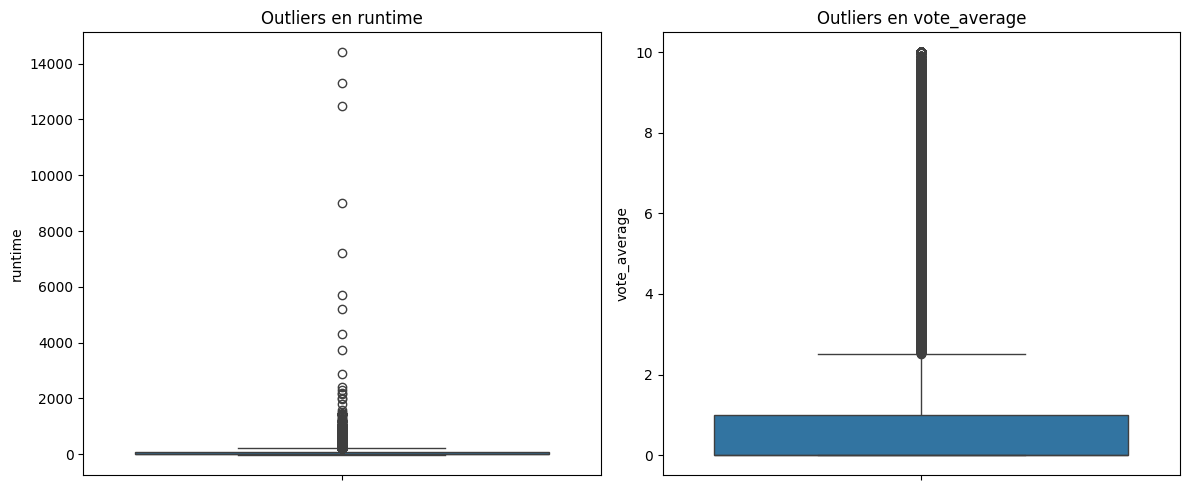

In [49]:
# Boxplots de runtime y vote_average para detectar outliers visualmente.
cols_to_check = ['runtime', 'vote_average']

plt.figure(figsize=(12, 5))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(y=movies[col])
    plt.title(f'Outliers en {col}')

plt.tight_layout()
plt.show()

#### Interpretación — runtime y vote_average (pre-tratamiento)

- **runtime**: la gran mayoría de las películas tiene una duración de entre ~60 y ~180 minutos (la caja es estrecha y baja). Sin embargo, hay muchos puntos por encima de los bigotes, incluyendo valores de más de 5.000 y hasta 14.400 minutos. Estos son claramente errores de carga.

- **vote_average**: el boxplot muestra que el dataset completo incluye muchas películas con rating 0, lo que aplana la distribución. Esto se debe a que aún no aplicamos el filtro de `vote_count > 100`. Hay también valores en 10 (rating perfecto) que podrían ser casos con muy pocos votos.

#### Boxplots de budget y revenue filtrando ceros
_Visualizar solo valores conocidos permite ver la distribución real sin distorsión._


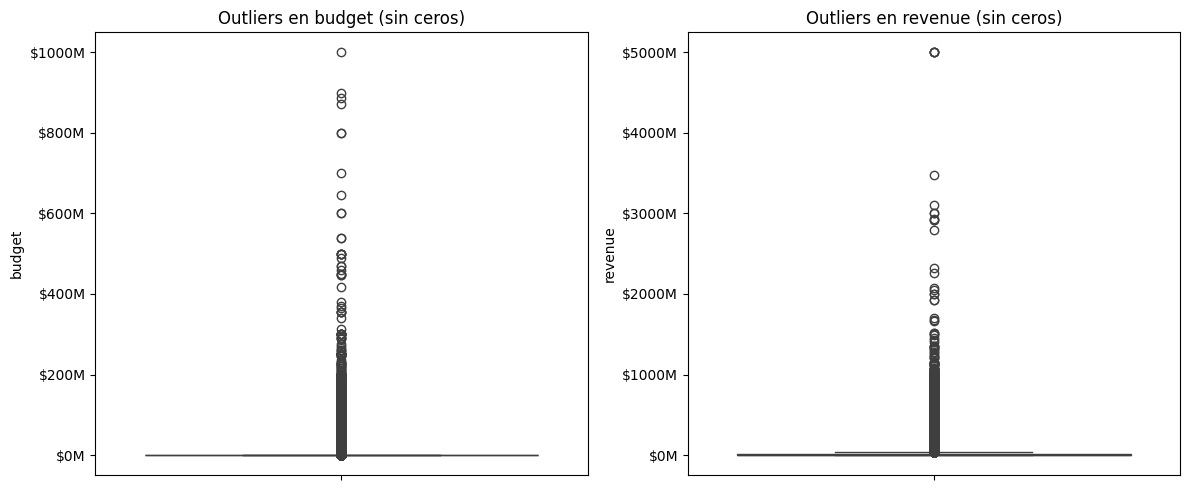

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=budget_valid, ax=axes[0])
axes[0].set_title('Outliers en budget (sin ceros)')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

sns.boxplot(y=revenue_valid, ax=axes[1])
axes[1].set_title('Outliers en revenue (sin ceros)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

#### Interpretación — budget y revenue (pre-tratamiento, sin ceros)

- **budget**: la caja está completamente aplastada cerca de $0, lo que indica que la mayoría de las películas con presupuesto conocido tienen valores bajos o moderados. Hay varios outliers por encima de $300M, con un máximo de $1.000M.

- **revenue**: patrón similar al budget. La caja está cerca de $0 con la mediana por debajo de $100M, y hay outliers que llegan hasta $5.000M (Avengers: Endgame, Avatar).

# 2. Técnicas de Visualización

## 2.1. Histogramas de Variables Numéricas

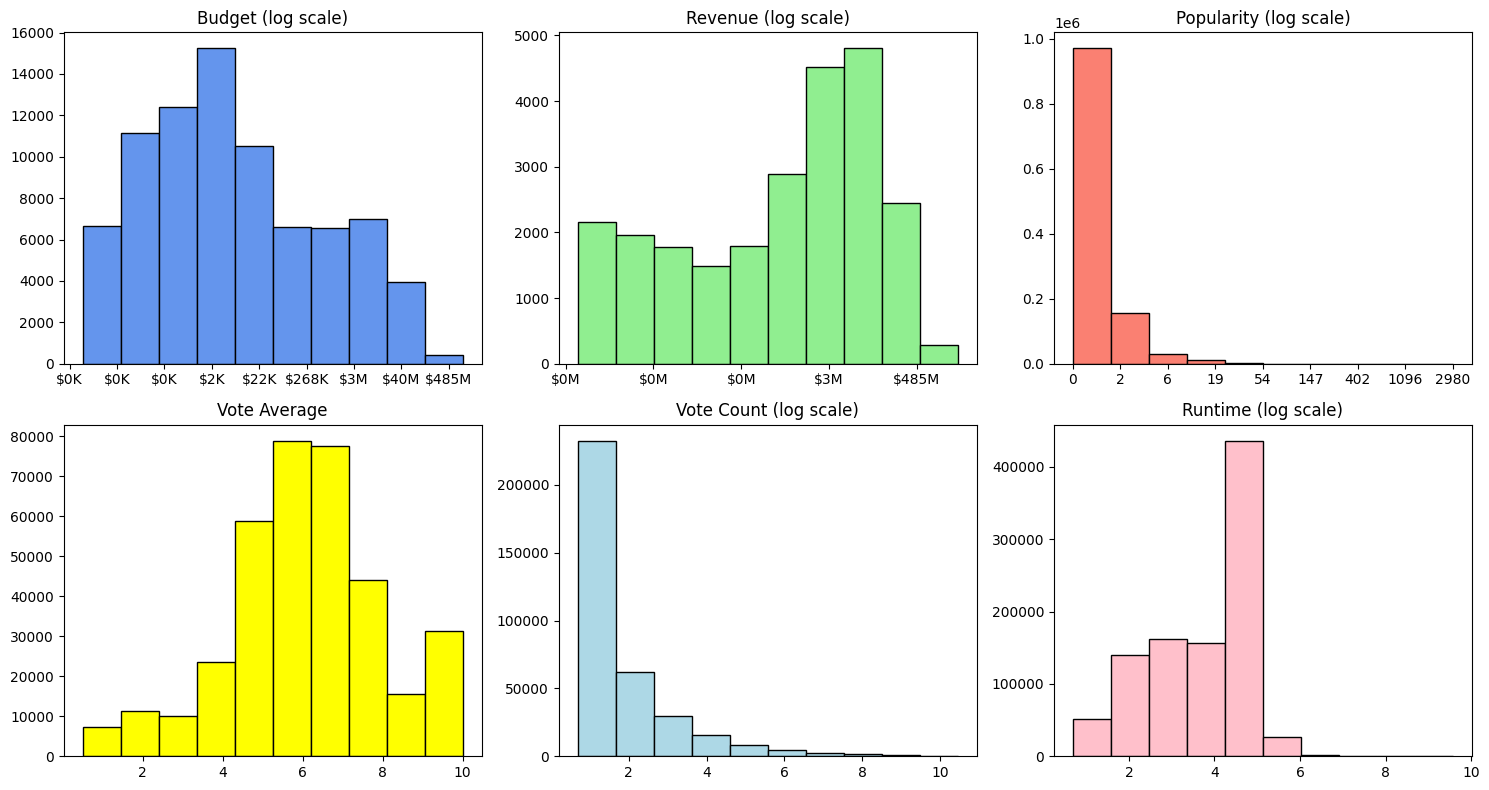

In [51]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# --- Budget ---
ax[0,0].hist(np.log1p(budget_valid), bins=10, color='cornflowerblue', edgecolor='black')
ax[0,0].set_title('Budget (log scale)')

# Nice original-scale tick labels
def log1p_inverse(y):
    return np.expm1(y)

ax[0,0].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M" if y >= 13 else f"${log1p_inverse(y)/1e3:.0f}K"
))

# --- Revenue ---
# valid_revenue = movies['revenue'][movies['revenue'] > 0]  # also drop negative
ax[0,1].hist(np.log1p(revenue_valid), bins=10, color='lightgreen', edgecolor='black')
ax[0,1].set_title('Revenue (log scale)')
ax[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M"
))

# --- Popularity ---
ax[0,2].hist(np.log1p(popularity_valid), bins=10, color='salmon', edgecolor='black')
ax[0,2].set_title('Popularity (log scale)')
ax[0,2].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"{log1p_inverse(y):.0f}"
))

# --- Vote Average ---
ax[1,0].hist(vote_average_valid, bins=10, color='yellow', edgecolor='black')
ax[1,0].set_title('Vote Average')

# --- Vote Count ---
ax[1,1].hist(np.log1p(vote_count_valid), bins=10, color='lightblue', edgecolor='black')
ax[1,1].set_title('Vote Count (log scale)')

# --- Rubntime ---
ax[1,2].hist(np.log1p(runtime_valid), bins=10, color='pink', edgecolor='black')
ax[1,2].set_title('Runtime (log scale)')

plt.tight_layout()
plt.show()

## 2.2. Graficos de Variables Categoricas


### Movies per moth

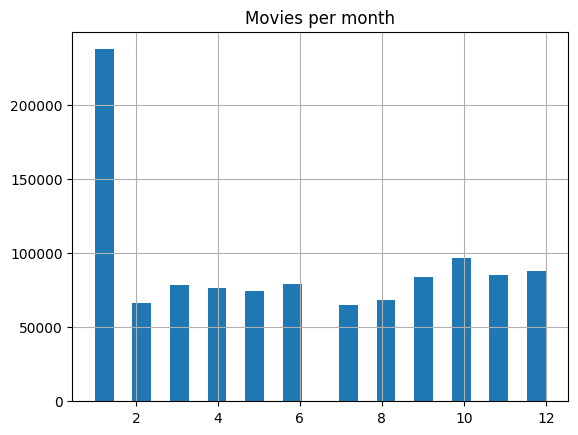

In [52]:
#standarize dates
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

movies['release_month'] = movies['release_date'].dt.month
ax = movies['release_month'].hist(bins=24)
ax.set_title('Movies per month')
plt.show()

### Idioma original de las películas

Visualizamos los más frecuentes mediante un gráfico de barras

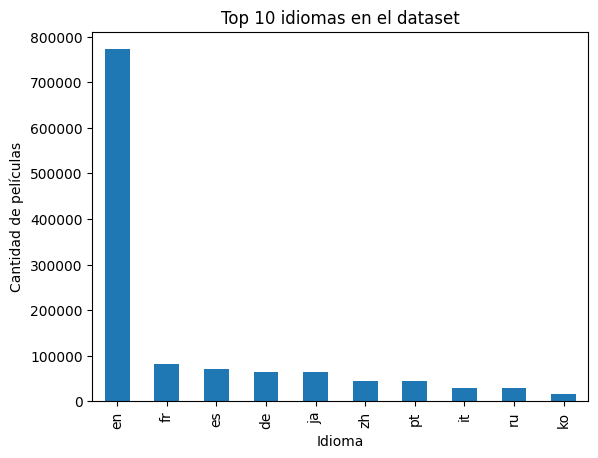

In [53]:
# Gráfico de barras con los idiomas más frecuentes
language_counts.head(10).plot(kind="bar")

plt.title("Top 10 idiomas en el dataset")
plt.xlabel("Idioma")
plt.ylabel("Cantidad de películas")
plt.show()

### Paises por Producción

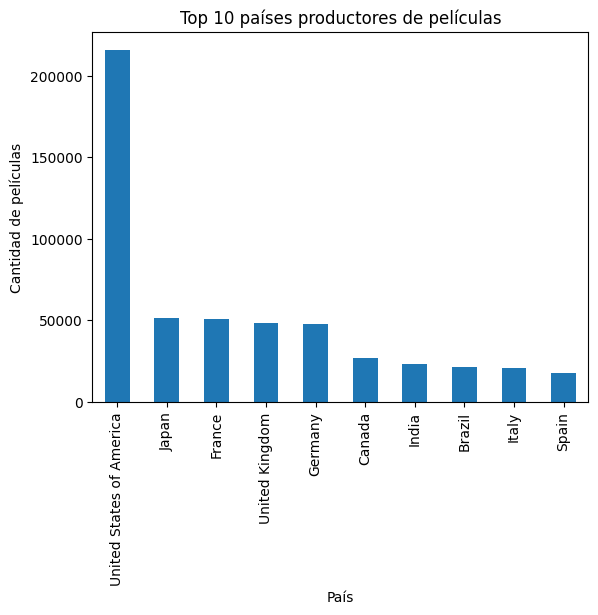

In [54]:
#Gráfico de países
country_counts.head(10).plot(kind="bar")

plt.title("Top 10 países productores de películas")
plt.xlabel("País")
plt.ylabel("Cantidad de películas")
plt.show()

### Mayores productoras de Peliculas

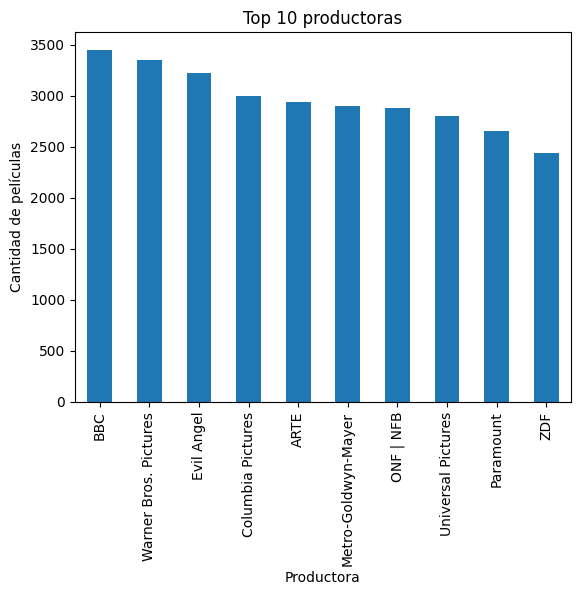

In [55]:
#Gráfico de productoras
company_counts.head(10).plot(kind="bar")

plt.title("Top 10 productoras")
plt.xlabel("Productora")
plt.ylabel("Cantidad de películas")
plt.show()

### Keywords mas frecuentes

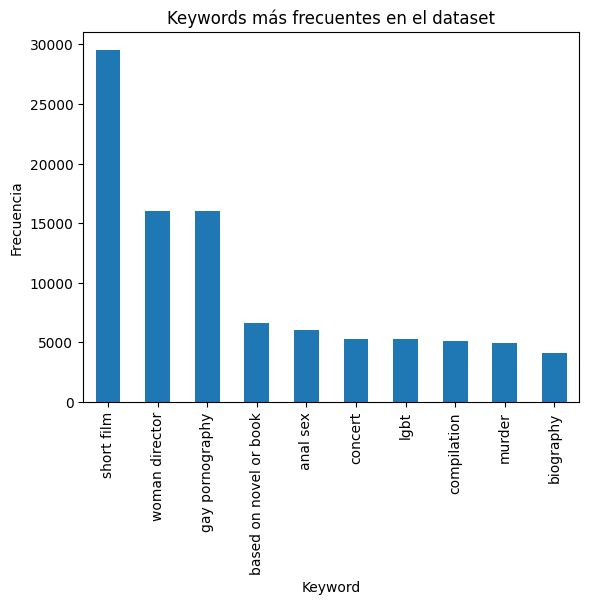

In [56]:
#Gráfico de keywords
keyword_counts.head(10).plot(kind="bar")

plt.title("Keywords más frecuentes en el dataset")
plt.xlabel("Keyword")
plt.ylabel("Frecuencia")
plt.show()

### Géneros de Películas

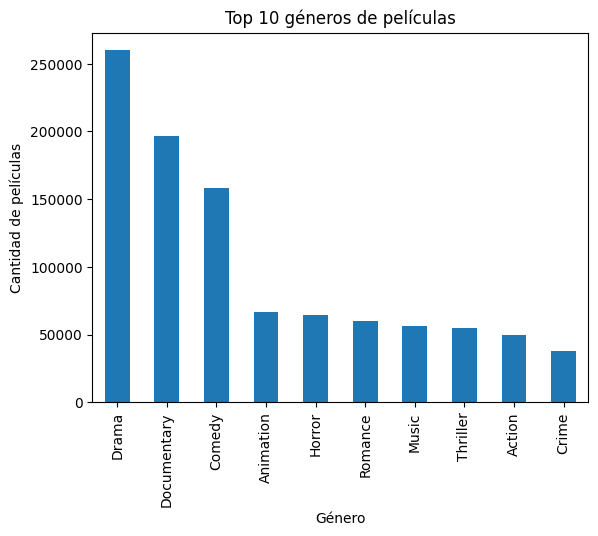

In [57]:
# Visualizar los géneros más frecuentes
genre_counts.head(10).plot(kind="bar")

plt.title("Top 10 géneros de películas")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.show()

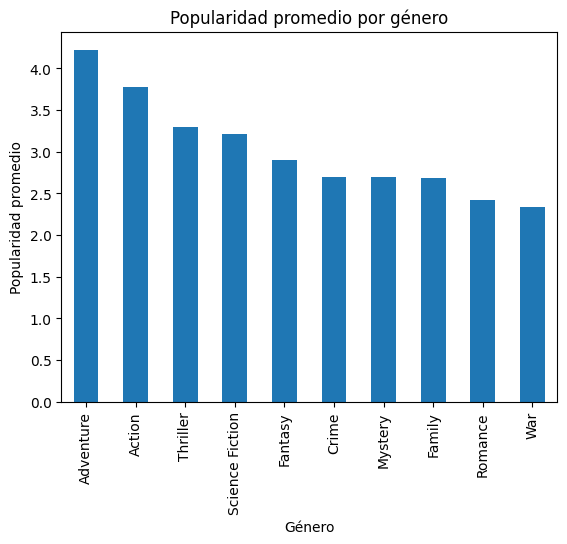

In [58]:
# Visualizar qué géneros tienen mayor popularidad promedio
genre_popularity.head(10).plot(kind="bar")

plt.title("Popularidad promedio por género")
plt.xlabel("Género")
plt.ylabel("Popularidad promedio")
plt.show()

## Películas duplicadas

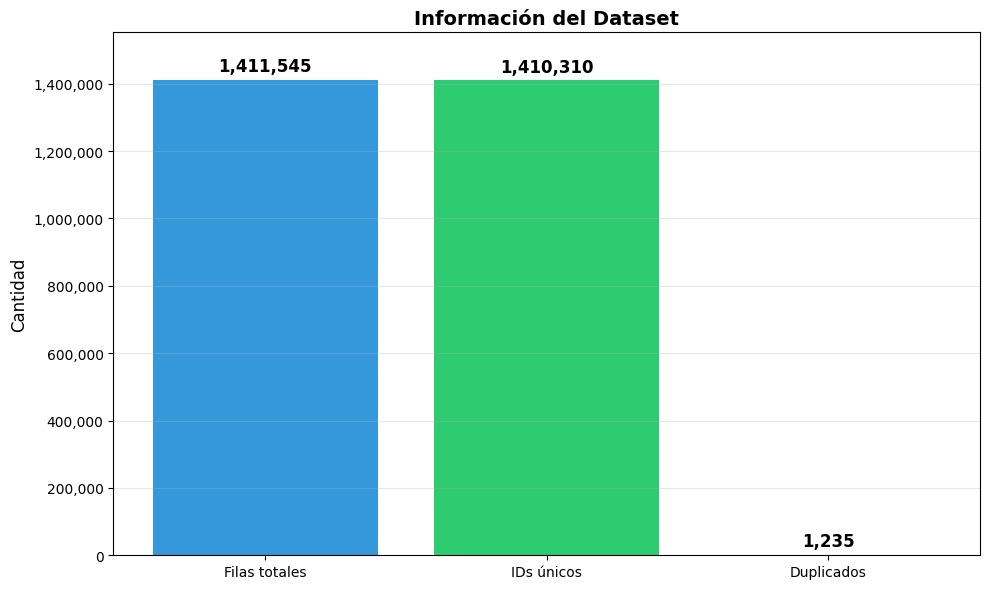

In [59]:
# Visualizar información del dataset
fig, ax = plt.subplots(figsize=(10, 6))

# Datos
categorias = ['Filas totales', 'IDs únicos', 'Duplicados']
valores = [len(movies), movies['id'].nunique(), len(movies) - movies['id'].nunique()]
colores = ['#3498db', '#2ecc71', '#e74c3c']

# Crear gráfico de barras
bars = ax.bar(categorias, valores, color=colores)

# Configurar etiquetas y título
ax.set_title('Información del Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad', fontsize=12)

# Formatear el eje Y para mostrar valores completos
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Ajustar escala del eje Y
max_val = max(valores)
ax.set_ylim(0, max_val * 1.1)

# Agregar valores sobre las barras
for bar, valor in zip(bars, valores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max_val * 0.01,
             f'{valor:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Agregar grid para mejor lectura
ax.grid(axis='y', alpha=0.3)

# Rotar etiquetas si es necesario
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 3. Problema de ML Supervisado

## 3.1. Descripcion del Problema de Aprendizaje Supervisado

Nuestro objetivo es preparar las variables predictoras para estimar el `vote_average` de una película. Es un problema de regresión. Filtramos las variables que no aportan información predictiva (identificadores, nombres, slogans) y nos enfocamos en metadatos como géneros, idiomas y métricas de producción.

Se plantea un escenario inspirado en plataformas de streaming como Netflix en el momento de evaluar la adquisición de contenido. En este contexto, la plataforma dispone de información de una película **después de su estreno en cines**, cuando ya se conocen datos como la recaudación (`revenue`) pero antes de que el título esté disponible en streaming. El objetivo es predecir el `vote_average` que tendrá la película a partir de sus características conocidas en ese momento, tales como género, presupuesto, duración, idioma, país de producción o recaudación en taquilla.

Este enfoque tiene aplicaciones reales en la industria, como la toma de decisiones sobre adquisición de contenido, priorización en catálogos o estimación del engagement esperado.

A partir de esta definición, se excluyen variables que no estarían disponibles en el momento de la adquisición. Por ejemplo, la variable `popularity` no se considera, ya que es calculada en función de la interacción de los usuarios dentro de la plataforma, una vez que la película ya fue incorporada al catálogo.

De esta manera, se asegura que el modelo utilice únicamente información disponible en un escenario realista de adquisición post-estreno.

## 3.2. Variable Target

### vote_average

# 4. Procesamiento y limpieza

## 4.1 Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.

En esta sección prepararemos el dataset filtrando aquellas películas con pocos votos para asegurar la confiabilidad de nuestra variable objetivo: `vote_average`.

### Limpieza de películas duplicadas

Se eliminan las filas con peliculas duplicadas

In [60]:
# remove duplicates
movies = movies.drop_duplicates(subset=['id'], keep='first')

### Filtrado por relevancia

Para que el modelo aprenda patrones significativos, filtramos el dataset para incluir solo:
- Películas con **más de 100 votos**: garantiza que `vote_average` sea una métrica estable y no esté sesgada por películas con muy pocos votos.
- Películas **no adultas** (`adult == False`): excluimos contenido adulto ya que sigue patrones muy distintos al cine convencional.

Dimensiones originales (sin duplicados): (1410310, 25)
Dimensiones tras filtrado (>100 votos, no adultas): (18080, 25)
Películas eliminadas: 1,392,230


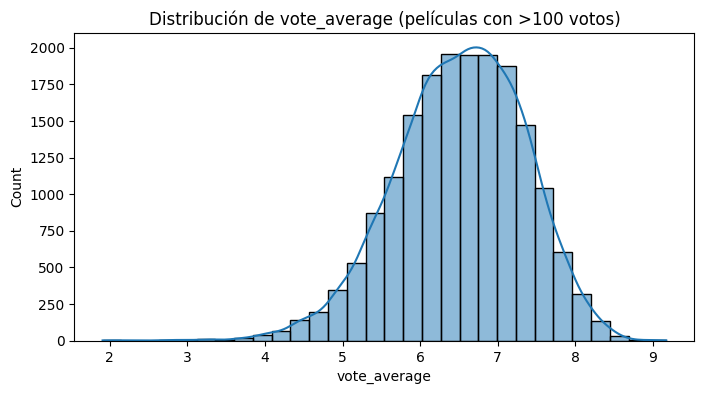

In [61]:
movies_filtered = movies[(movies['vote_count'] > 100) & (movies['adult'] == False)].copy()

print(f"Dimensiones originales (sin duplicados): {movies.shape}")
print(f"Dimensiones tras filtrado (>100 votos, no adultas): {movies_filtered.shape}")
print(f"Películas eliminadas: {len(movies) - len(movies_filtered):,}")

# Distribución del target en el dataset filtrado
plt.figure(figsize=(8, 4))
sns.histplot(movies_filtered['vote_average'], bins=30, kde=True)
plt.title('Distribución de vote_average (películas con >100 votos)')
plt.xlabel('vote_average')
plt.show()

### 4.1 Realizar el split del dataset (ej: train y test).

Para evitar el sesgo de información (data leakage), realizamos la división en conjuntos de entrenamiento y prueba antes de aplicar transformaciones que dependan de la distribución de los datos.

In [62]:
from sklearn.model_selection import train_test_split

features_cols = ['genres', 'original_language', 'production_companies', 'production_countries',
                 'runtime', 'budget', 'revenue']
target = 'vote_average'

X = movies_filtered[features_cols].copy()
y = movies_filtered[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (14464, 7)
X_test shape: (3616, 7)


### 4.2 Tratamiento de outliers

La estrategia varía según la variable:

- **`runtime`**: se aplica **capping por percentiles (p1–p99)**. Los valores extremos corresponden a errores de carga (películas de 14.000 minutos), por lo que recortarlos es correcto.

- **`vote_average`**: **no se aplica capping**. Todos los valores están dentro del rango válido de TMDB (0–10), y el filtro previo de `vote_count > 100` ya garantiza la confiabilidad de los ratings. Aplicar capping descartaría información legítima (películas genuinamente mal o excepcionalmente bien valoradas).

- **`budget` y `revenue`**: **no se aplica capping**. Los outliers en estas columnas son valores reales: Avatar, Avengers: Endgame y otras producciones de alto presupuesto/recaudación son casos legítimos. En cambio, se aplica una **transformación logarítmica (`log1p`)** para comprimir la escala y reducir el sesgo de la distribución sin descartar información.

Los ceros de `budget` y `revenue` se reemplazan por `NaN` antes del `log1p`, ya que en TMDB el valor `0` representa un dato desconocido, no una película con presupuesto o recaudación nula.

In [63]:
def fit_cap_outliers(series):
    return series.quantile(0.01), series.quantile(0.99)

def apply_cap_outliers(series, lower, upper):
    return series.clip(lower, upper)

# runtime: capping p1-p99 (fitteado solo en train)
lower, upper = fit_cap_outliers(X_train['runtime'])
X_train['runtime'] = apply_cap_outliers(X_train['runtime'], lower, upper)
X_test['runtime'] = apply_cap_outliers(X_test['runtime'], lower, upper)

# budget y revenue: reemplazar 0 por NaN (0 = dato desconocido en TMDB) y luego log1p
for col in ['budget', 'revenue']:
    X_train[col] = X_train[col].replace(0, np.nan)
    X_test[col] = X_test[col].replace(0, np.nan)
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

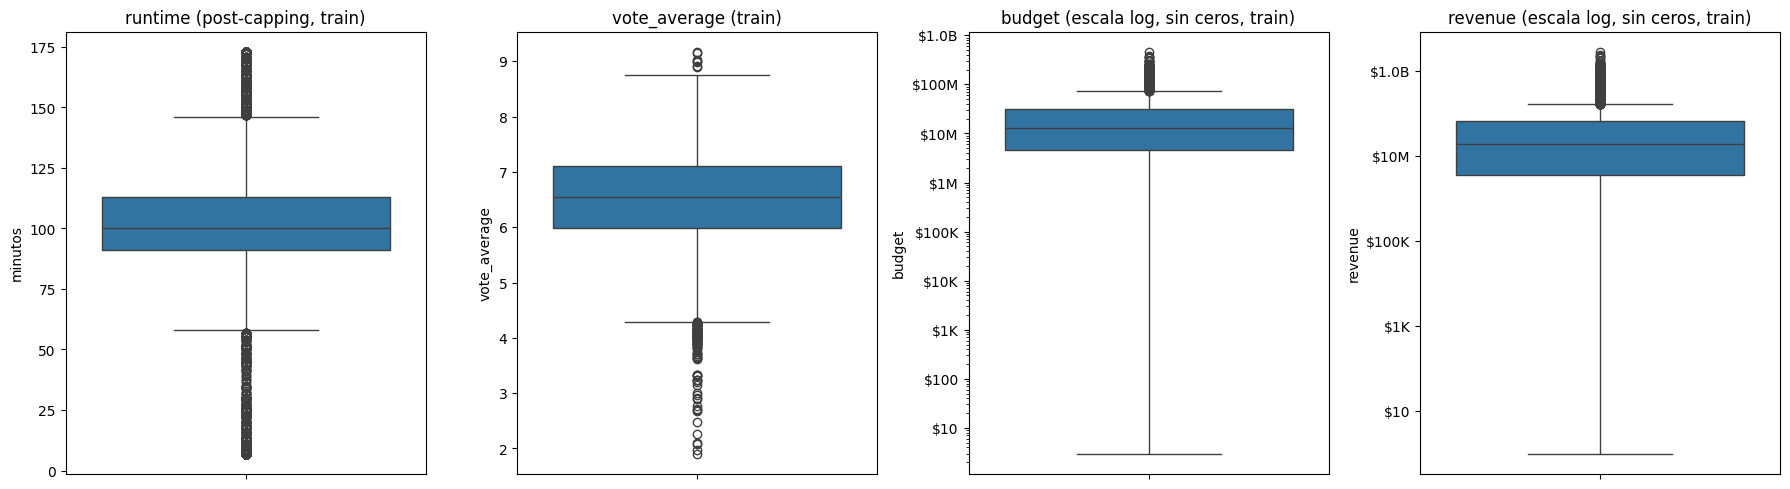

In [64]:
# Visualización post-tratamiento sobre train
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.boxplot(y=X_train['runtime'], ax=axes[0])
axes[0].set_title('runtime (post-capping, train)')
axes[0].set_ylabel('minutos')

sns.boxplot(y=y_train, ax=axes[1])
axes[1].set_title('vote_average (train)')

def smart_dollar_formatter(x, _):
    if x >= 1e9:
        return f'${x/1e9:.1f}B'
    elif x >= 1e6:
        return f'${x/1e6:.0f}M'
    elif x >= 1e3:
        return f'${x/1e3:.0f}K'
    return f'${x:.0f}'

budget_orig = movies_filtered.loc[X_train.index, 'budget']
budget_orig = budget_orig[budget_orig > 0]
sns.boxplot(y=budget_orig, ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('budget (escala log, sin ceros, train)')
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(smart_dollar_formatter))

revenue_orig = movies_filtered.loc[X_train.index, 'revenue']
revenue_orig = revenue_orig[revenue_orig > 0]
sns.boxplot(y=revenue_orig, ax=axes[3])
axes[3].set_yscale('log')
axes[3].set_title('revenue (escala log, sin ceros, train)')
axes[3].yaxis.set_major_formatter(ticker.FuncFormatter(smart_dollar_formatter))

plt.tight_layout()
plt.show()

#### Interpretación — post-tratamiento de outliers

- **runtime**: la distribución quedó acotada entre ~25 y ~175 minutos. La caja concentra la mayoría de los valores alrededor de los 90–100 minutos, duración típica de una película. Los valores de miles de minutos (errores de carga) fueron eliminados.

- **vote_average**: la distribución refleja el rango real del dataset filtrado (películas con más de 100 votos). La mediana se ubica alrededor de 6.5, con la mayoría de los valores concentrados entre 5.5 y 7.5. Los extremos (~1.9 y ~9.2) corresponden a casos genuinos y se conservan.

- **budget y revenue (escala log, valores originales sin ceros)**: al visualizar en escala logarítmica los valores reales (en dólares), se aprecia que la distribución es mucho más compacta que en los boxplots pre-tratamiento. La caja ocupa varios órdenes de magnitud de forma razonablemente uniforme, lo que justifica el uso de `log1p` en lugar de capping: los blockbusters de $500M–$5.000M siguen presentes pero ya no dominan la escala lineal, reduciendo el sesgo sin descartar información legítima.

# 5. Feature Engineering

En esta fase creamos nuevas variables a partir de las existentes y preparamos las features para el modelado.

Se simplificaron algunas variables categóricas que presentaban una gran cantidad de valores posibles, como el idioma y el país de producción.
En particular, las variables `original_language` y `production_countries` presentaban una gran cantidad de categorías distintas.

Para abordar este problema, en lugar de trabajar con todas las categorías originales, se agruparon en clases más generales (por ejemplo, inglés vs. otros idiomas, o Estados Unidos vs. resto del mundo), con el objetivo de facilitar el modelado y evitar generar una gran cantidad de variables.
Esta simplificación permite mantener información relevante sobre el origen de las películas, al mismo tiempo que reduce la dimensionalidad del dataset y mejora la interpretabilidad de los resultados.

Importante: el feature engineering se aplica **por separado** sobre `X_train` y `X_test` para evitar data leakage.


In [65]:
# Feature engineering sobre X_train y X_test por separado

def apply_feature_engineering(X):
    X = X.copy()

    # Convertir genres a lista si no lo es
    X['genres'] = X['genres'].apply(
        lambda x: x if isinstance(x, list) else [g.strip() for g in str(x).split(',') if g.strip()]
    )

    # Idioma: binario inglés vs otros
    X['is_english'] = X['original_language'].apply(lambda x: 1 if x == 'en' else 0)

    # País: binario USA vs resto
    X['is_usa'] = X['production_countries'].apply(
        lambda x: 1 if 'United States of America' in str(x) else 0
    )

    # Tomar solo el primer género
    X['genres'] = X['genres'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'Unknown'
    )

    # Tomar solo la primera productora
    X['production_companies'] = X['production_companies'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0
        else (x.split(',')[0].strip() if isinstance(x, str) and x else 'Unknown')
    )

    X.drop(columns=['original_language', 'production_countries'], inplace=True)
    return X

X_train = apply_feature_engineering(X_train)
X_test = apply_feature_engineering(X_test)

print('X_train shape:', X_train.shape)
print(X_train.head())


X_train shape: (14464, 7)
          genres     production_companies  runtime     budget    revenue  \
2271      Comedy        Columbia Pictures      103  16.648724  17.901319   
3063   Animation  Mainframe Entertainment       85        NaN        NaN   
10265     Comedy  Zentropa Entertainments       95  14.914123        NaN   
12402     Comedy           Epithète Films      102  14.914123  14.733332   
17752      Drama                Le Bureau      144  15.607270  14.077876   

       is_english  is_usa  
2271            1       1  
3063            1       0  
10265           0       0  
12402           0       0  
17752           1       1  


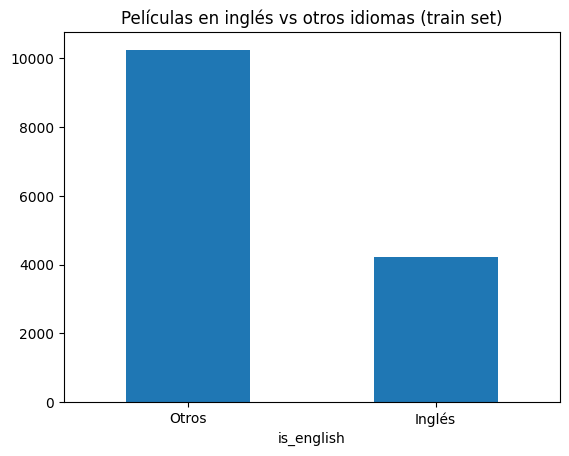

In [66]:
X_train['is_english'].value_counts().plot(kind='bar')
plt.title("Películas en inglés vs otros idiomas (train set)")
plt.xticks([0,1], ['Otros', 'Inglés'], rotation=0)
plt.show()

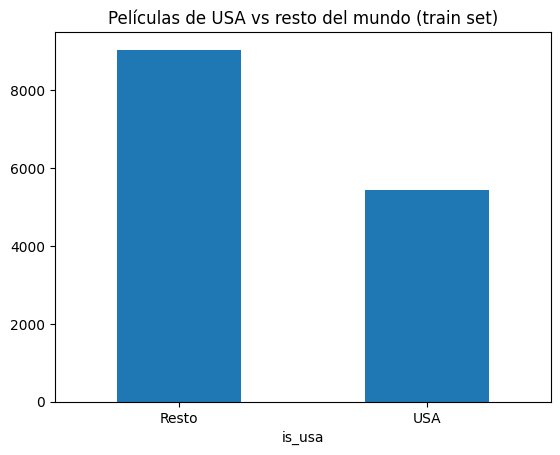

In [67]:
X_train['is_usa'].value_counts().plot(kind='bar')
plt.title("Películas de USA vs resto del mundo (train set)")
plt.xticks([0,1], ['Resto', 'USA'], rotation=0)
plt.show()

# 6. Codificación y Escalado

Aplicamos One-Hot Encoding a las variables categóricas y estandarizamos las numéricas mediante un Pipeline de Scikit-Learn.

In [68]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identificamos tipos de columnas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()

print('Columnas numéricas:', num_cols)
print('Columnas categóricas:', cat_cols)

# Definimos transformadores
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# max_categories=20 agrupa productoras/géneros poco frecuentes en 'infrequent'
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

# Combinamos en un Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Ajustamos sobre train, transformamos ambos
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Nombres de columnas para el DataFrame resultante
feature_names = (num_cols +
                 preprocessor.named_transformers_['cat']
                 .named_steps['onehot'].get_feature_names_out(cat_cols).tolist())

X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
print(f'Shape post-encoding: {X_train_df.shape}')
X_train_df.head()


Columnas numéricas: ['runtime', 'budget', 'revenue', 'is_english', 'is_usa']
Columnas categóricas: ['genres', 'production_companies']
Shape post-encoding: (14464, 45)


,runtime,budget,revenue,is_english,is_usa,genres_Action,genres_Adventure,genres_Animation,genres_Comedy,genres_Crime,...,production_companies_Touchstone Pictures,production_companies_TriStar Pictures,production_companies_United Artists,production_companies_Universal Pictures,production_companies_Unknown,production_companies_Walt Disney Pictures,production_companies_Walt Disney Productions,production_companies_Warner Bros. Animation,production_companies_Warner Bros. Pictures,production_companies_infrequent_sklearn
0,0.058656,0.300718,0.770020,0.642262,0.774825,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.707092,0.094272,0.116782,0.642262,-1.290614,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.281676,-1.034169,0.116782,-1.556998,-1.290614,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.016115,-1.034169,-1.007021,-1.556998,-1.290614,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.802862,-0.500748,-1.374691,0.642262,0.774825,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# 7. Reducción de Dimensionalidad

Aplicamos técnicas de selección de features (basadas en correlación) y reducción de dimensionalidad (PCA) para simplificar nuestro conjunto de datos manteniendo la mayor parte de la información.

### 7.1 Análisis de Correlación

Identificamos variables con baja correlación con el objetivo o alta correlación entre sí (redundancia).

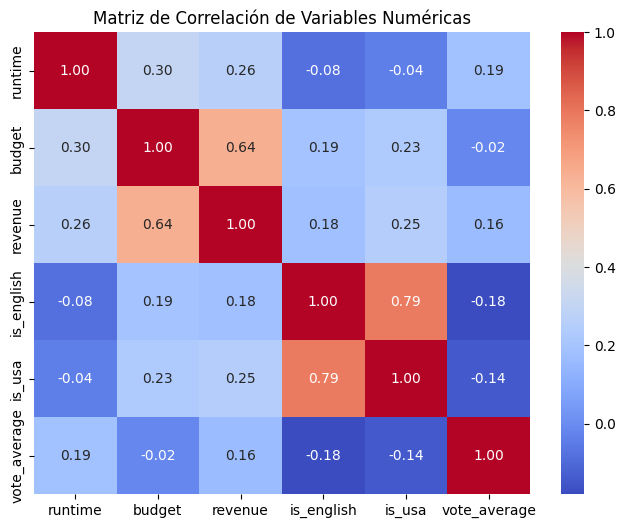

In [69]:
# Correlación sobre variables numéricas (pre-encoding, post-FE)
# is_english e is_usa son int64 tras el feature engineering
num_cols_corr = [c for c in X_train.select_dtypes(include=['int64', 'float64']).columns]
corr_df = X_train[num_cols_corr].copy()
corr_df['vote_average'] = y_train

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()


### 7.2 Aplicación de PCA (Análisis de Componentes Principales)

Reducimos el espacio de características procesado a un conjunto de componentes principales.

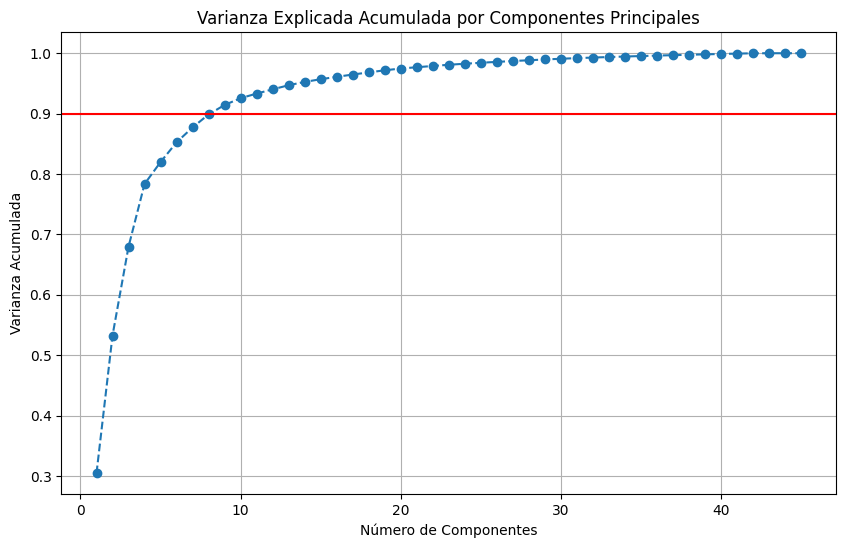

Número de componentes para explicar el 90% de la varianza: 9


In [70]:
from sklearn.decomposition import PCA

# Aplicamos PCA sin reducir inicialmente para ver la varianza explicada
pca = PCA()
X_pca = pca.fit_transform(X_train_df)

# Varianza acumulada
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='-')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid()
plt.show()

# Seleccionamos componentes que expliquen el 90% de la varianza
n_components_90 = np.argmax(explained_variance_ratio >= 0.9) + 1
print(f"Número de componentes para explicar el 90% de la varianza: {n_components_90}")

### 7.3 Análisis de Loadings

Para interpretar los componentes principales, analizamos la contribución (pesos) de las variables originales a los dos primeros componentes.

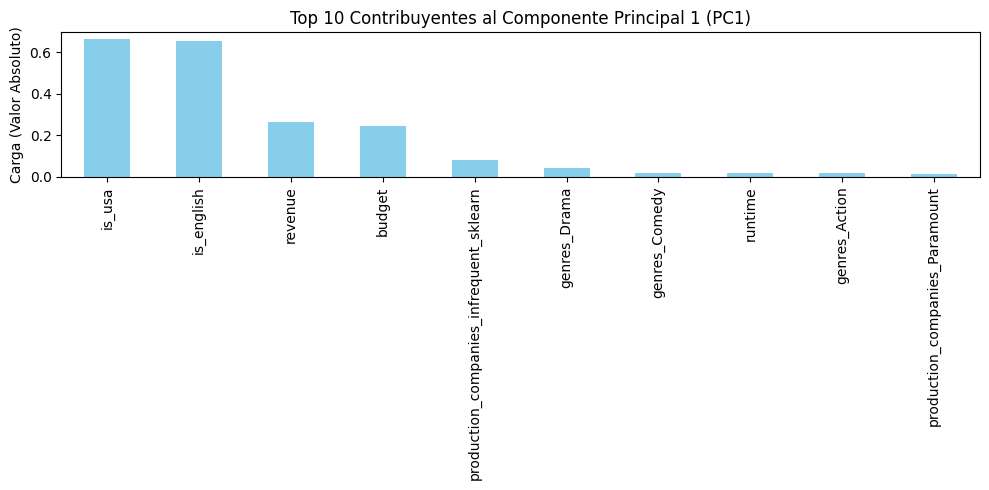

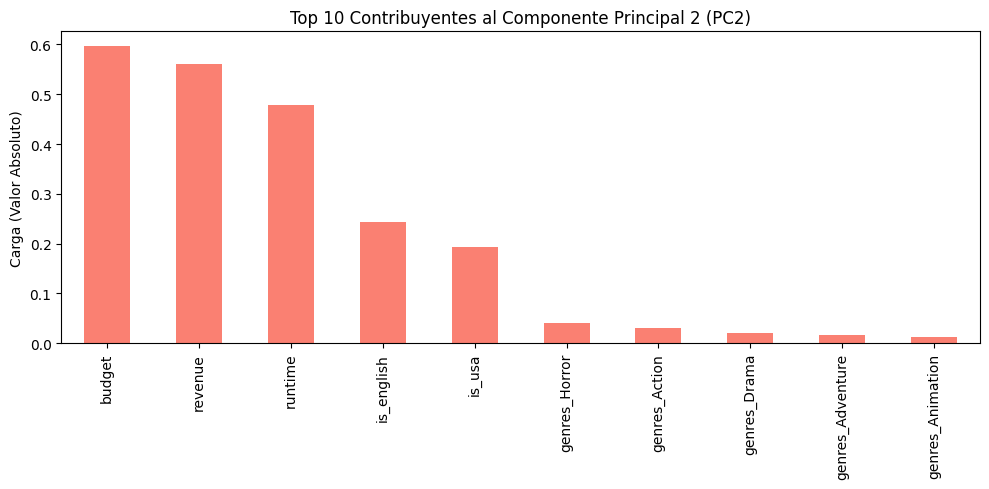

In [71]:
# Obtenemos los pesos (loadings) de los componentes
# pca.components_.T tiene shape (n_features, n_components)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_names
)

# Top 10 variables que más contribuyen al PC1
plt.figure(figsize=(10, 5))
loadings['PC1'].abs().sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Contribuyentes al Componente Principal 1 (PC1)')
plt.ylabel('Carga (Valor Absoluto)')
plt.tight_layout()
plt.show()

# Top 10 variables que más contribuyen al PC2
plt.figure(figsize=(10, 5))
loadings['PC2'].abs().sort_values(ascending=False).head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Contribuyentes al Componente Principal 2 (PC2)')
plt.ylabel('Carga (Valor Absoluto)')
plt.tight_layout()
plt.show()


### 7.4 Visualización del Espacio de Características Reducido

Graficamos las películas en el nuevo espacio definido por PC1 y PC2, coloreando por `vote_average`.

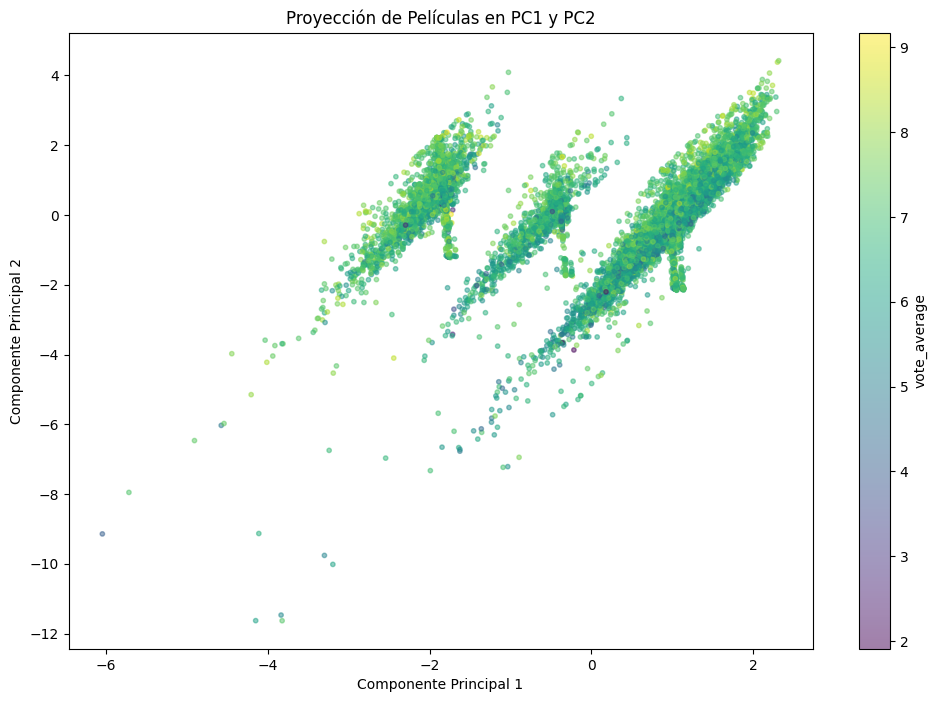

In [72]:
# Scatter plot de PC1 vs PC2 coloreado por la variable objetivo
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train.values, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='vote_average')
plt.title('Proyección de Películas en PC1 y PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# 8. Conclusiones Finales

Tras completar el análisis y preparación de los datos de TMDB, podemos concluir:

1. **Estructura del Dataset:** El conjunto de datos presenta una alta dimensionalidad y una gran cantidad de variables categóricas. La limpieza y extracción del metadato principal permitió simplificar el análisis manteniendo la información clave.
2. **Calidad de Datos:** La clasificación de nulos permitió entender la naturaleza de los datos faltantes (MAR/MNAR). El filtrado por `vote_count > 100` fue fundamental para garantizar que la variable objetivo sea robusta.
3. **Representatividad mediante PCA:** El análisis demostró que es posible reducir drásticamente el número de variables (logrando explicar el 90% de la varianza) utilizando componentes principales, lo cual optimiza el dataset para futuras etapas de modelado.
4. **Visualización:** La proyección en el espacio de componentes principales permite analizar la distribución general de las películas. Sin embargo, no se observan agrupamientos claramente definidos según el vote_average, lo que sugiere que las variables consideradas no separan de forma evidente las películas en función de su puntuación.